### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from utils import * 
from FAPT import * 
from pulse_optimization import *
import sympy as sp

In [2]:
s = Simulation()
rH = 2
rW = 1
def fitted_pulse_symbolic(t, p):
    tg_sym, wd_sym, amp_sym = p
    return amp_sym, wd_sym

H_base, M_base, M_inv_0_base = prepare_floquet_functions(pulse_shape_builder=fitted_pulse_symbolic, p_names=["tg", "wd", "amp"], s=s, rH=rH, rW=rW, include_geometric=False, include_micromotion=False, include_g_correction=False, verbose=False)

param_ranges = {"wd_offset": (-0.005, 0.005), "amp_offset": (-0.05, 0.05)}
param_names = list(param_ranges.keys())

def bind_tg_fixed_floquet_functions(tg_target, s):
    cos_wd, cos_amp = compute_cos_params(s, tg_target)
    def absolute_parameters(offsets):
        values = dict(zip(param_names, offsets))
        return cos_wd + values["wd_offset"], cos_amp + values["amp_offset"]

    def H_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return H_base(t, tg_target, wd, amp)

    def M_func(t, *offsets):
        wd, amp = absolute_parameters(offsets)
        return M_base(t, tg_target, wd, amp)

    def M_inv_0_func(*offsets):
        wd, amp = absolute_parameters(offsets)
        return M_inv_0_base(tg_target, wd, amp)

    H_func.is_time_dependent = getattr(H_base, "is_time_dependent", True)

    return H_func, M_func, M_inv_0_func

In [ ]:
tg_list = np.linspace(100.0, 1000.0, 5)
results_virtual_z = [optimize_iswap_at_gate_time(tg, s, param_ranges, *bind_tg_fixed_floquet_functions(tg, s), verbose = False, correct_zz=True) for tg in tqdm(tg_list, desc="Virtual-Z Gate-Time Sweep", unit="tg")]
result_keys_virtual_z = results_virtual_z[0].keys()
sweep_data_virtual_z = {key: [result[key] for result in results_virtual_z] for key in result_keys_virtual_z}

Virtual-Z Gate-Time Sweep:  20%|██        | 1/5 [00:03<00:14,  3.51s/tg]

phases:  [-0.23559143  0.3375721  -1.16973254]
tg_final: 101.5044 ns | infid_floq_pop: 3.2815e-02 | infid_floq_proc: 1.6977e-02 | infid_direct_pop: 3.1001e-02 | infid_direct_proc: 2.1944e-02


Virtual-Z Gate-Time Sweep:  40%|████      | 2/5 [00:07<00:11,  3.94s/tg]

phases:  [-0.2440335   0.08206107 -0.63035872]
tg_final: 325.5095 ns | infid_floq_pop: 1.4871e-03 | infid_floq_proc: 2.6240e-03 | infid_direct_pop: 1.0333e-03 | infid_direct_proc: 3.9296e-03


Virtual-Z Gate-Time Sweep:  60%|██████    | 3/5 [00:13<00:09,  4.66s/tg]

phases:  [ 0.25162555 -0.16957731 -0.1004219 ]
tg_final: 550.6503 ns | infid_floq_pop: 4.5960e-04 | infid_floq_proc: 2.4460e-04 | infid_direct_pop: 4.2604e-04 | infid_direct_proc: 4.9115e-04


Virtual-Z Gate-Time Sweep:  80%|████████  | 4/5 [00:19<00:05,  5.41s/tg]

phases:  [-0.24709891 -0.421208   -0.54568712]
tg_final: 775.7900 ns | infid_floq_pop: 2.6274e-04 | infid_floq_proc: 7.1435e-04 | infid_direct_pop: 2.1236e-04 | infid_direct_proc: 8.6838e-04


Virtual-Z Gate-Time Sweep: 100%|██████████| 5/5 [00:27<00:00,  5.43s/tg]

phases:  [-0.24971114  0.32233514 -1.00645503]
tg_final: 999.4766 ns | infid_floq_pop: 1.9529e-04 | infid_floq_proc: 1.1300e-04 | infid_direct_pop: 1.9800e-04 | infid_direct_proc: 1.4644e-04


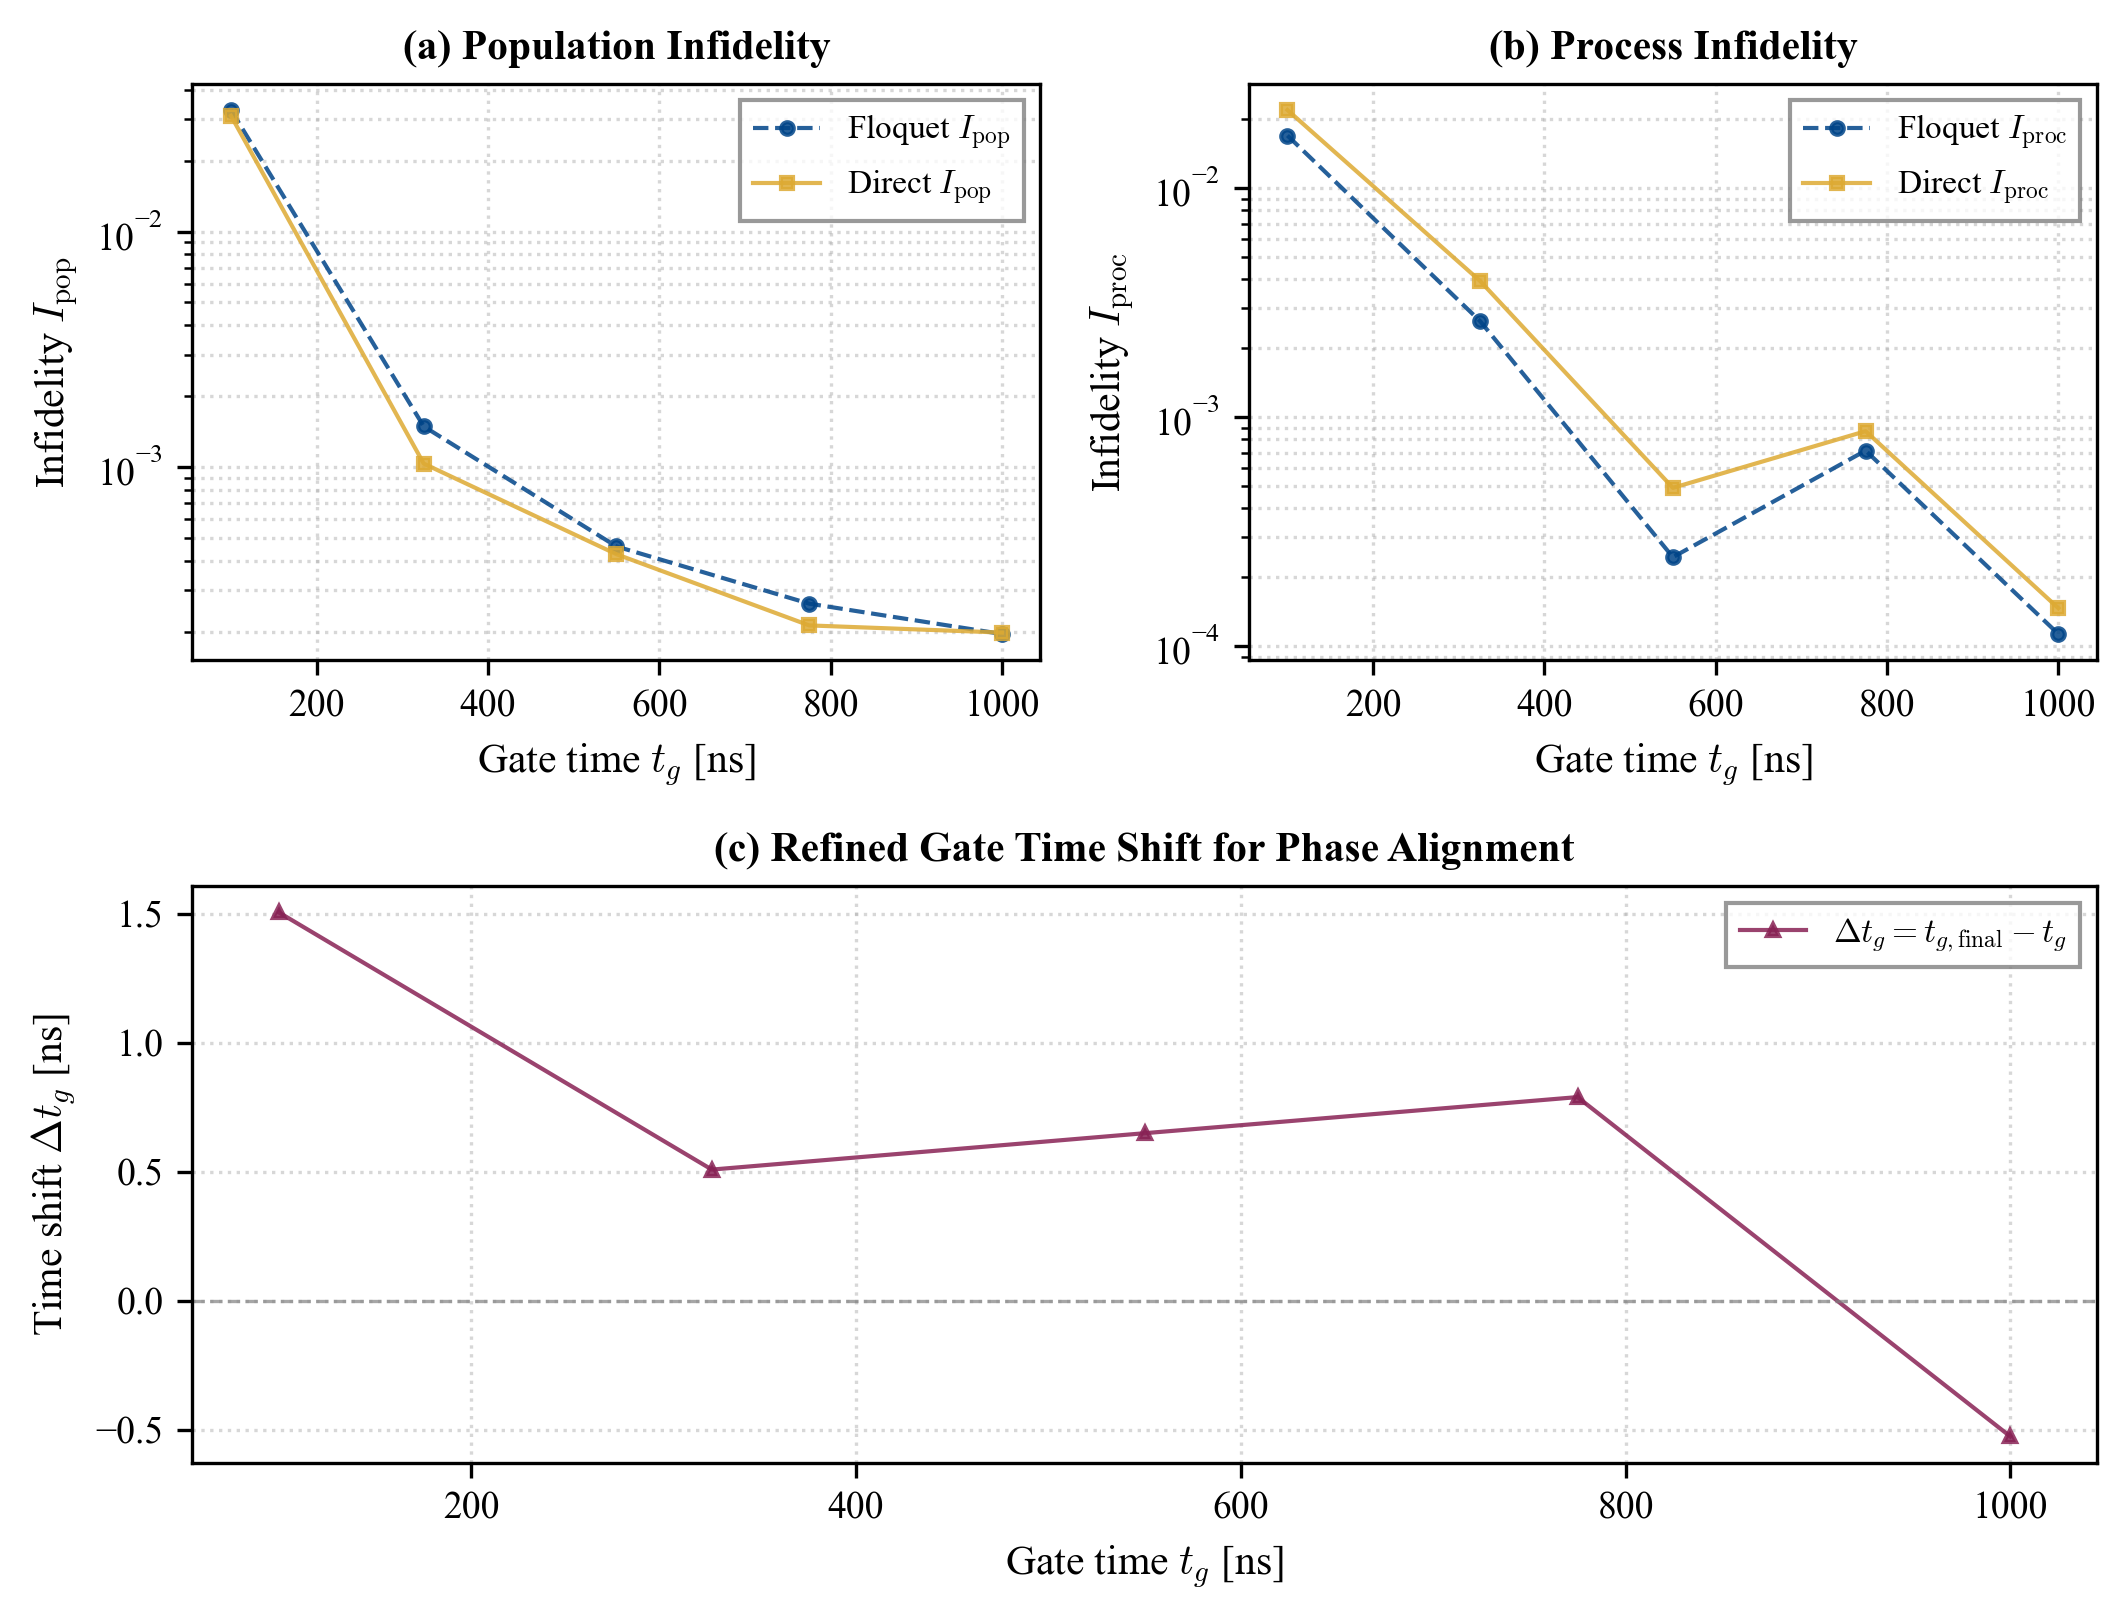

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


# ==============================================================================
# Setup & Helper
# ==============================================================================
def setup_paper_style():
    """Sets Matplotlib defaults for scientific publication layouts."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "axes.labelsize": 10,
        "font.size": 10,
        "legend.fontsize": 8.0,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.titlesize": 11,
        "axes.titlesize": 10,
        "lines.linewidth": 1.0,
        "lines.markersize": 3.0,
    })


def _parse_results(results):
    """Utility to safely convert a list of dicts or a dict of lists into numpy arrays."""
    if isinstance(results, list):
        keys = results[0].keys()
        return {k: np.array([res[k] for res in results]) for k in keys}
    return {k: np.array(v) for k, v in results.items()}


# ==============================================================================
# Plot-Funktion angepasst auf sweep_data_virtual_z
# ==============================================================================
def plot_thesis_combined_fidelity_results(
    tg_list,
    sweep_data_virtual_z,
    save_path="Figure/cos_tg_fid.pdf",
):
    """Generiert den 3-Panel Thesis-Plot passend zu den Keys aus optimize_iswap_at_gate_time:

    (a) Population Infidelity (Floquet vs. Direct SE)
    (b) Process Infidelity (Floquet vs. Direct SE)
    (c) Refined Gate Time Shift Δtg = tg_final - tg_target über die volle Breite.
    """
    setup_paper_style()
    data_vz = _parse_results(sweep_data_virtual_z)

    n_pts = len(tg_list)
    mark_stride = max(1, n_pts // 25)

    # Grid Layout: Oben (a, b), Unten (c über volle Breite)
    fig = plt.figure(figsize=(7.2, 5.5), dpi=300)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, :])

    c_floq = "#004488"   # Blue
    c_mes = "#DDAA33"    # Gold / Yellow
    c_shift = "#882255"  # Wine / Purple
    m_floq, m_mes = "o", "s"

    # --- Panel (a): Population Infidelity ---
    ax_a.semilogy(
        tg_list,
        data_vz["infid_floq_pop"],
        f"{m_floq}--",
        color=c_floq,
        markevery=mark_stride,
        alpha=0.85,
        label=r"Floquet $I_{\mathrm{pop}}$",
    )
    ax_a.semilogy(
        tg_list,
        data_vz["infid_direct_pop"],
        f"{m_mes}-",
        color=c_mes,
        markevery=mark_stride,
        alpha=0.85,
        label=r"Direct $I_{\mathrm{pop}}$",
    )
    ax_a.set_xlabel(r"Gate time $t_g$ [ns]")
    ax_a.set_ylabel(r"Infidelity $I_{\mathrm{pop}}$")
    ax_a.set_title(r"(a) Population Infidelity", fontweight="bold")
    ax_a.grid(True, which="both", linestyle=":", alpha=0.5)
    ax_a.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

    # --- Panel (b): Process Infidelity ---
    ax_b.semilogy(
        tg_list,
        data_vz["infid_floq_proc"],
        f"{m_floq}--",
        color=c_floq,
        markevery=mark_stride,
        alpha=0.85,
        label=r"Floquet $I_{\mathrm{proc}}$",
    )
    ax_b.semilogy(
        tg_list,
        data_vz["infid_direct_proc"],
        f"{m_mes}-",
        color=c_mes,
        markevery=mark_stride,
        alpha=0.85,
        label=r"Direct $I_{\mathrm{proc}}$",
    )
    ax_b.set_xlabel(r"Gate time $t_g$ [ns]")
    ax_b.set_ylabel(r"Infidelity $I_{\mathrm{proc}}$")
    ax_b.set_title(r"(b) Process Infidelity", fontweight="bold")
    ax_b.grid(True, which="both", linestyle=":", alpha=0.5)
    ax_b.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

    # --- Panel (c): Gate Time Shift Δtg = tg_final - tg_target ---
    delta_tg = np.array(data_vz["tg_final"]) - np.array(tg_list)

    ax_c.plot(
        tg_list,
        delta_tg,
        "^-",
        color=c_shift,
        markevery=mark_stride,
        alpha=0.85,
        label=r"$\Delta t_g = t_{g,\mathrm{final}} - t_g$",
    )
    ax_c.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax_c.set_xlabel(r"Gate time $t_g$ [ns]")
    ax_c.set_ylabel(r"Time shift $\Delta t_g$ [ns]")
    ax_c.set_title(r"(c) Refined Gate Time Shift for Phase Alignment", fontweight="bold")
    ax_c.grid(True, linestyle=":", alpha=0.5)
    ax_c.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

    plt.tight_layout()

    output_file = Path(save_path)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()
plot_thesis_combined_fidelity_results(
    tg_list=tg_list,
    sweep_data_virtual_z=sweep_data_virtual_z,
    save_path="Figure/cos_tg_fid.pdf"
)

Now let's sweep the flux bias and to find a value, that automatically implements the the desired phase relation

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


# ==============================================================================
# Helper & Setup
# ==============================================================================
def setup_paper_style():
    """Sets Matplotlib defaults for scientific publication layouts."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "axes.labelsize": 10,
        "font.size": 10,
        "legend.fontsize": 8.0,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.titlesize": 11,
        "axes.titlesize": 10,
        "lines.linewidth": 1.0,
        "lines.markersize": 3.0,
    })


def _parse_results(results):
    """Utility to safely convert a list of dicts or a dict of lists into numpy arrays."""
    if isinstance(results, list):
        keys = results[0].keys()
        return {k: np.array([res[k] for res in results]) for k in keys}
    return {k: np.array(v) for k, v in results.items()}


# ==============================================================================
# 1. Main Combined Thesis Figure (Subplots a, b, c)
# ==============================================================================
def plot_thesis_combined_fidelity_results(
    tg_list,
    sweep_data_virtual_z,
    sweep_data_gate_time,
    save_path="Figure/cos_tg_fid.pdf",
):
    """Generates a combined 3-panel thesis plot without leakage:

    (a) Virtual-Z Population Infidelity (I_pop)
    (b) Virtual-Z Process Infidelity (I_proc)
    (c) Gate Time Correction Process Infidelity (I_proc) across full width.
    """
    setup_paper_style()
    data_vz = _parse_results(sweep_data_virtual_z)
    data_gt = _parse_results(sweep_data_gate_time)

    n_pts = len(tg_list)
    mark_stride = max(1, n_pts // 25)

    # Grid Layout: Top row (a, b), Bottom row (c over full width)
    fig = plt.figure(figsize=(7.2, 5.5), dpi=300)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, :])  # Full width for panel (c)

    c_floq = "#004488"  # Blue
    c_mes = "#DDAA33"   # Yellow / Gold
    m_floq, m_mes = "o", "s"

    # --- Panel (a): Virtual-Z Population Infidelity ---
    ax_a.semilogy(
        tg_list,
        data_vz["floq_pop"],
        f"{m_floq}--",
        color=c_floq,
        markevery=mark_stride,
        alpha=0.85,
        label=r"Floquet $I_{\mathrm{pop}}$",
    )
    ax_a.semilogy(
        tg_list,
        data_vz["mes_pop"],
        f"{m_mes}-",
        color=c_mes,
        markevery=mark_stride,
        alpha=0.85,
        label=r"$\mathrm{mesolve}\ I_{\mathrm{pop}}$",
    )
    ax_a.set_xlabel(r"Gate time $t_g$ [ns]")
    ax_a.set_ylabel(r"Infidelity $I_{\mathrm{pop}}$")
    ax_a.set_title(r"(a) Virtual-Z: Population Infidelity", fontweight="bold")
    ax_a.grid(True, which="both", linestyle=":", alpha=0.5)
    ax_a.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

    # --- Panel (b): Virtual-Z Process Infidelity ---
    ax_b.semilogy(
        tg_list,
        data_vz["floq_proc"],
        f"{m_floq}--",
        color=c_floq,
        markevery=mark_stride,
        alpha=0.85,
        label=r"Floquet $I_{\mathrm{proc}}$",
    )
    ax_b.semilogy(
        tg_list,
        data_vz["mes_proc"],
        f"{m_mes}-",
        color=c_mes,
        markevery=mark_stride,
        alpha=0.85,
        label=r"$\mathrm{mesolve}\ I_{\mathrm{proc}}$",
    )
    ax_b.set_xlabel(r"Gate time $t_g$ [ns]")
    ax_b.set_ylabel(r"Infidelity $I_{\mathrm{proc}}$")
    ax_b.set_title(r"(b) Virtual-Z: Process Infidelity", fontweight="bold")
    ax_b.grid(True, which="both", linestyle=":", alpha=0.5)
    ax_b.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

    # --- Panel (c): Gate Time Correction Process Infidelity (Full Width) ---
    ax_c.semilogy(
        tg_list,
        data_gt["floq_proc"],
        f"{m_floq}--",
        color=c_floq,
        markevery=mark_stride,
        alpha=0.85,
        label=r"Floquet $I_{\mathrm{proc}}$",
    )
    ax_c.semilogy(
        tg_list,
        data_gt["mes_proc"],
        f"{m_mes}-",
        color=c_mes,
        markevery=mark_stride,
        alpha=0.85,
        label=r"$\mathrm{mesolve}\ I_{\mathrm{proc}}$",
    )
    ax_c.set_xlabel(r"Gate time $t_g$ [ns]")
    ax_c.set_ylabel(r"Infidelity $I_{\mathrm{proc}}$")
    ax_c.set_title(r"(c) Gate Time Correction: Process Infidelity", fontweight="bold")
    ax_c.grid(True, which="both", linestyle=":", alpha=0.5)
    ax_c.legend(frameon=True, fancybox=False, edgecolor="gray", loc="upper right")

    plt.tight_layout()

    output_file = Path(save_path)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()


# ==============================================================================
# 2. Separate Figure: Isolated Leakage over I_pop Plot
# ==============================================================================
def plot_leakage_over_ipop(
    tg_list,
    sweep_data,
    save_path="Figure/cos_tg_fid_leakage.pdf",
):
    """Generates an isolated figure displaying only Leakage / I_pop over tg."""
    setup_paper_style()
    data = _parse_results(sweep_data)

    n_pts = len(tg_list)
    mark_stride = max(1, n_pts // 25)

    fig, ax = plt.subplots(figsize=(4.5, 3.0), dpi=300)

    c_pop = "#882255"  # Purple/Wine color

    if "floq_leakage_proc" in data and "floq_pop" in data:
        ratio_pop = data["floq_leakage_proc"] / data["floq_pop"]

        ax.plot(
            tg_list,
            1-ratio_pop,
            "s-",
            color=c_pop,
            markevery=mark_stride,
            alpha=0.85,
            label=r"$\mathrm{Leakage} / I_{\mathrm{pop}}$ (Floquet)",)

    ax.set_xlabel(r"Gate time $t_g$ [ns]")
    ax.set_ylabel(r"$\mathrm{Leakage} / I_{\mathrm{pop}}$")
    ax.set_title(r"Leakage Relative to Population Infidelity", fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(frameon=True, fancybox=False, edgecolor="gray", loc="best")
    ax.set_yscale('log')

    plt.tight_layout()

    output_file = Path(save_path)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_file, bbox_inches="tight")
    plt.show()


# --- Execution Example ---
# 1. Hauptabbildung mit den 3 zusammengefassten Plots (a, b, c)
# plot_thesis_combined_fidelity_results(
#     tg_list,
#     sweep_data_virtual_z,
#     sweep_data_gate_time,
#     save_path="Figure/cos_tg_fid.pdf",
# )

# # 2. Separate Leakage-Abbildung (nur Leakage / I_pop)
# plot_leakage_over_ipop(
#     tg_list,
#     sweep_data_virtual_z,
#     save_path="Figure/cos_tg_fid_leakage.pdf",
# )